### PH464/564: Scientific Computing II
***J.S. Hazboun***

___

# Homework 3
### Due: Monday, Oct 20th at 11:59pm Pacific
---

# HW 3

The purpose of this assignment is to get exercise some basic sampling skills, focusing on rejection and importance sampling.

Take the following probability density function:

$$p(x) = 0.164\exp{\left(-\frac{(x-10)^4}{2\cdot 8^2}\right)}$$


1. Use _rejection sampling_ to draw 1000 samples from this distribution.  Show that the samples you've drawn are correctly distributed according to this probability density function.

2. Use _importance sampling_ to estimate the expectation value of $x$, and compare it to the mean of the samples you drew in part 1.

3. Calculate the expectation value of $x^2$.

### Part 1



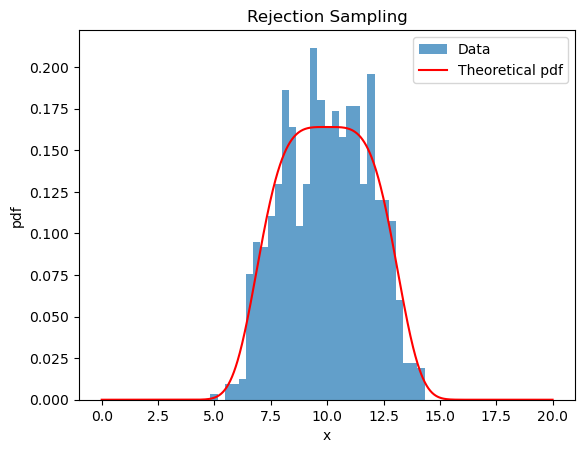

In [42]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.distributions import norm

# Define this function so I can use it later
def p(x):
    return 0.164 * np.exp(-(x - 10)**4/(2 * 8**2))

# Create a function to do rejection sampling, I use a while loop to ensure
# I can pull 1000 numbers every time, though it does cause the
# computation time to vary when I run it
def rejection_sample(N):
    samples = []
    probdens = []
    count = 0
    
    size = np.linspace(0,20,10000)
    for i in size:
        probdens.append(p(i))
    
    while count < N:
        z = np.random.uniform(0,20)
        h = np.random.uniform(0, max(probdens))
        
        if h <= p(z):
            samples.append(z)
            count += 1
    
    return samples

x = np.linspace(0, 20, 1000)

# Pull the data
data = rejection_sample(1000)

plt.hist(data, alpha=0.7, bins=30, density=True, label='Data')
plt.plot(x, p(x), label='Theoretical pdf', color='red')
plt.xlabel('x')
plt.ylabel('pdf')
plt.title('Rejection Sampling')
plt.legend()
plt.show()
# Looks like it follows pretty well, if I had more terms it does look closer to the pdf but we were asked for 1000

### Part 2

Expectation value of x: 10.009497799212257
Mean of samples from part 1: 9.990993086297713


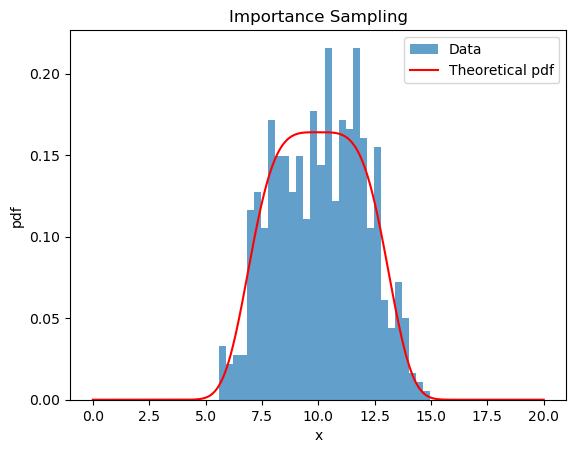

In [43]:
# Create an unnormalized version of the pdf
def q(x):
    return 3*0.164 * np.exp(-(x - 10)**4/(2 * 8**2))

# Sampling distribution
# Only using 1000 draws to match with part 1
sample = norm(10,4)
samplevalues = sample.rvs(1000)

# Create weights
weights = q(samplevalues)/sample.pdf(samplevalues)

# Find the expectation value
expectedvalue = np.sum(samplevalues * weights)/np.sum(weights)

# Comparison
print("Expectation value of x:", expectedvalue)
print("Mean of samples from part 1:", np.mean(data))

# These are pretty close, which is good! But to verify my method is correct 
# I want to go one step further and practice plotting this

maxheight = np.max(weights)
accept = np.random.uniform(0, maxheight, 1000) < weights

plt.hist(samplevalues[accept], alpha=0.7, bins=30, density=True, label='Data')
plt.plot(x, p(x), label='Theoretical pdf', color='red')
plt.xlabel('x')
plt.ylabel('pdf')
plt.title('Importance Sampling')
plt.legend()
plt.show()
# Looks good! Again it matches better with more terms, but I wanted to stay consistent with part 1

### Part 3

In [44]:
# Since we want to find expectation value of h(theta) = x^2, we
# substitute that value in the sum
expectedvalue2= np.sum(samplevalues**2 * weights)/np.sum(weights)

# Comparison
print("Expectation value of x^2:", expectedvalue2)
print("Expectation value of x:", expectedvalue)
print("Mean of samples from part 1:", np.mean(data))

Expectation value of x^2: 104.13333857979963
Expectation value of x: 10.009497799212257
Mean of samples from part 1: 9.990993086297713
